<a href="https://colab.research.google.com/github/DiegoFau/Alura_store_latam/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [26]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [27]:
#Asignamos nombres a las tiendas, concatenamos las tiendas y calculamos el total de vtas de cada una

tienda['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

#Concatenamos las tiendas
todas_las_tiendas = pd.concat([tienda, tienda2, tienda3, tienda4])

#Sumamos todas las ventas de cada tienda por separado
facturacion_total = todas_las_tiendas.groupby('Tienda')['Precio'].sum().rename('Total')
facturacion_total



,Total
Tienda,
Tienda 1,1.150880e+09
Tienda 2,1.116344e+09
Tienda 3,1.098020e+09
Tienda 4,1.038376e+09


In [28]:
#Convertir a DF, para graficos
facturacion_total_df = facturacion_total.reset_index()
facturacion_total_df.columns = ['Tienda', 'Total']

facturacion_total_df

,Tienda,Total
0,Tienda 1,1.150880e+09
1,Tienda 2,1.116344e+09
2,Tienda 3,1.098020e+09
3,Tienda 4,1.038376e+09


# 2. Ventas por categoría

In [29]:
#Contamos las ventas por categorias de prodcuto
ventas_categoria = todas_las_tiendas.groupby(['Tienda', 'Categoría del Producto']).size().rename('Cantidad')

#Ordenamos las categorias por cantidad dentro de cada tienda
ventas_categoria = ventas_categoria.groupby(level=0, group_keys=False).apply(lambda x: x.sort_values(ascending=False))
ventas_categoria

Tienda    Categoría del Producto 
Tienda 1  Muebles                    465
          Electrónicos               448
          Juguetes                   324
          Electrodomésticos          312
          Deportes y diversión       284
          Instrumentos musicales     182
          Libros                     173
          Artículos para el hogar    171
Tienda 2  Muebles                    442
          Electrónicos               422
          Juguetes                   313
          Electrodomésticos          305
          Deportes y diversión       275
          Instrumentos musicales     224
          Libros                     197
          Artículos para el hogar    181
Tienda 3  Muebles                    499
          Electrónicos               451
          Juguetes                   315
          Electrodomésticos          278
          Deportes y diversión       277
          Libros                     185
          Artículos para el hogar    177
          Instrumentos musicales     177
Tienda 4  Muebles                    480
          Electrónicos               451
          Juguetes                   338
          Deportes y diversión       277
          Electrodomésticos          254
          Artículos para el hogar    201
          Libros                     187
          Instrumentos musicales     170
Name: Cantidad, dtype: int64

In [30]:
#Convertir a DF, para graficos
ventas_categoria_df = ventas_categoria.reset_index()
ventas_categoria_df.columns = ['Tienda', 'Categoría', 'Cantidad']

ventas_categoria_df

,Tienda,Categoría,Cantidad
0,Tienda 1,Muebles,465
1,Tienda 1,Electrónicos,448
2,Tienda 1,Juguetes,324
3,Tienda 1,Electrodomésticos,312
4,Tienda 1,Deportes y diversión,284
5,Tienda 1,Instrumentos musicales,182
6,Tienda 1,Libros,173
7,Tienda 1,Artículos para el hogar,171
8,Tienda 2,Muebles,442
9,Tienda 2,Electrónicos,422


# 3. Calificación promedio de la tienda


In [31]:
#Calcular el promedio de calificaciones de cada tienda
calificacion_promedio = todas_las_tiendas.groupby('Tienda')['Calificación'].mean()
calificacion_promedio

,Calificación
Tienda,
Tienda 1,3.976685
Tienda 2,4.037304
Tienda 3,4.048326
Tienda 4,3.995759


In [32]:
#Convertir a DF, para graficos y redondear a 2
calificacion_promedio_df = calificacion_promedio.reset_index()
calificacion_promedio_df.columns = ['Tienda', 'Calificación']
calificacion_promedio_df['Calificación'] = calificacion_promedio_df['Calificación'].round(2)
calificacion_promedio_df

,Tienda,Calificación
0,Tienda 1,3.98
1,Tienda 2,4.04
2,Tienda 3,4.05
3,Tienda 4,4.00


# 4. Productos más y menos vendidos

In [33]:
#Contamos las ventas por tienda y producto
ventas_productos = todas_las_tiendas.groupby(['Tienda', 'Producto']).size().rename('Total')

#Ordenamos los productos por cantidad dentro de cada tienda
ventas_productos = ventas_productos.groupby(level=0, group_keys=False).apply(lambda x: x.sort_values(ascending=False))

#Colab no va a mostrar todas tiendas, pero puedes ver los datos con .loc
ventas_productos

Tienda    Producto                   
Tienda 1  Armario                        60
          TV LED UHD 4K                  60
          Microondas                     60
          Secadora de ropa               58
          Mesa de noche                  56
                                         ..
Tienda 4  Ciencia de datos con Python    38
          Refrigerador                   38
          Guitarra acústica              37
          Armario                        34
          Guitarra eléctrica             33
Name: Total, Length: 204, dtype: int64

In [34]:
# Determinar la cantidad de productos distintos por tienda, para definir si hacemos un top 3 5 o 10
cantidad_productos = todas_las_tiendas.groupby('Tienda')['Producto'].nunique()
cantidad_productos

,Producto
Tienda,
Tienda 1,51
Tienda 2,51
Tienda 3,51
Tienda 4,51


In [35]:
#Obtenemos los 5 más y menos vendidos de cada tienda

top_5_productos = ventas_productos.groupby(level=0).head(5)
bottom_5_productos = ventas_productos.groupby(level=0).tail(5)

top_5_productos, bottom_5_productos

(Tienda    Producto                 
 Tienda 1  Armario                      60
           TV LED UHD 4K                60
           Microondas                   60
           Secadora de ropa             58
           Mesa de noche                56
 Tienda 2  Iniciando en programación    65
           Microondas                   62
           Batería                      61
           Pandereta                    58
           Guitarra acústica            58
 Tienda 3  Kit de bancas                57
           Mesa de comedor              56
           Cama king                    56
           Set de ollas                 55
           Mesa de noche                55
 Tienda 4  Cama box                     62
           Cubertería                   59
           Cama king                    56
           Dashboards con Power BI      56
           Carrito de control remoto    55
 Name: Total, dtype: int64,
 Tienda    Producto                   
 Tienda 1  Mochila                  

In [36]:
#Convertir a DF, para graficos
ventas_productos_df = ventas_productos.reset_index()
ventas_productos_df.columns = ['Tienda', 'Producto', 'Total']
ventas_productos_df

,Tienda,Producto,Total
0,Tienda 1,Armario,60
1,Tienda 1,TV LED UHD 4K,60
2,Tienda 1,Microondas,60
3,Tienda 1,Secadora de ropa,58
4,Tienda 1,Mesa de noche,56
...,...,...,...
199,Tienda 4,Ciencia de datos con Python,38
200,Tienda 4,Refrigerador,38
201,Tienda 4,Guitarra acústica,37
202,Tienda 4,Armario,34


In [37]:
# Convertir top 5 a DF
top_5_productos_df = top_5_productos.reset_index()
top_5_productos_df.columns = ['Tienda', 'Producto', 'Total']

# Convertir bottom 5 a DF
bottom_5_productos_df = bottom_5_productos.reset_index()
bottom_5_productos_df.columns = ['Tienda', 'Producto', 'Total']

#Si quieres verlo como tabla llamar de a uno.
top_5_productos_df, bottom_5_productos_df

(      Tienda                   Producto  Total
 0   Tienda 1                    Armario     60
 1   Tienda 1              TV LED UHD 4K     60
 2   Tienda 1                 Microondas     60
 3   Tienda 1           Secadora de ropa     58
 4   Tienda 1              Mesa de noche     56
 5   Tienda 2  Iniciando en programación     65
 6   Tienda 2                 Microondas     62
 7   Tienda 2                    Batería     61
 8   Tienda 2                  Pandereta     58
 9   Tienda 2          Guitarra acústica     58
 10  Tienda 3              Kit de bancas     57
 11  Tienda 3            Mesa de comedor     56
 12  Tienda 3                  Cama king     56
 13  Tienda 3               Set de ollas     55
 14  Tienda 3              Mesa de noche     55
 15  Tienda 4                   Cama box     62
 16  Tienda 4                 Cubertería     59
 17  Tienda 4                  Cama king     56
 18  Tienda 4    Dashboards con Power BI     56
 19  Tienda 4  Carrito de control remoto

# 5. Envío promedio por tienda

In [38]:
#Calculo del costo promedio de envio por tienda
costo_envio_promedio = todas_las_tiendas.groupby('Tienda')['Costo de envío'].mean()
costo_envio_promedio

,Costo de envío
Tienda,
Tienda 1,26018.609580
Tienda 2,25216.235693
Tienda 3,24805.680373
Tienda 4,23459.457167


In [39]:
#Convertir a DF, para graficos y redondear a 2
costo_envio_promedio_df = costo_envio_promedio.reset_index()
costo_envio_promedio_df.columns = ['Tienda', 'Envío promedio']
costo_envio_promedio_df['Envío promedio'] = costo_envio_promedio_df['Envío promedio'].round(2)
costo_envio_promedio_df

,Tienda,Envío promedio
0,Tienda 1,26018.61
1,Tienda 2,25216.24
2,Tienda 3,24805.68
3,Tienda 4,23459.46


#**Graficos**

##Facturación total por tienda

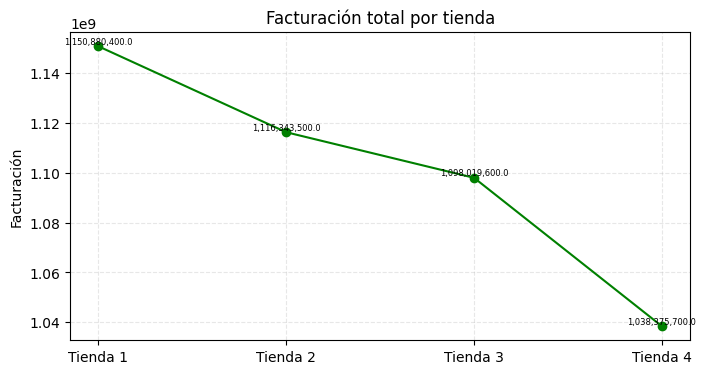

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(facturacion_total_df['Tienda'], facturacion_total_df['Total'], marker='o', color='green')

plt.title('Facturación total por tienda')
plt.ylabel('Facturación')
plt.grid(True, linestyle='--', alpha=0.3)

for i, valor in enumerate(facturacion_total_df['Total']):
    plt.text(i, valor, f"{valor:,}",     # formato con separador de miles
        ha='center', va='bottom', fontsize=6)

plt.show()

##Distribución de categorías por tienda

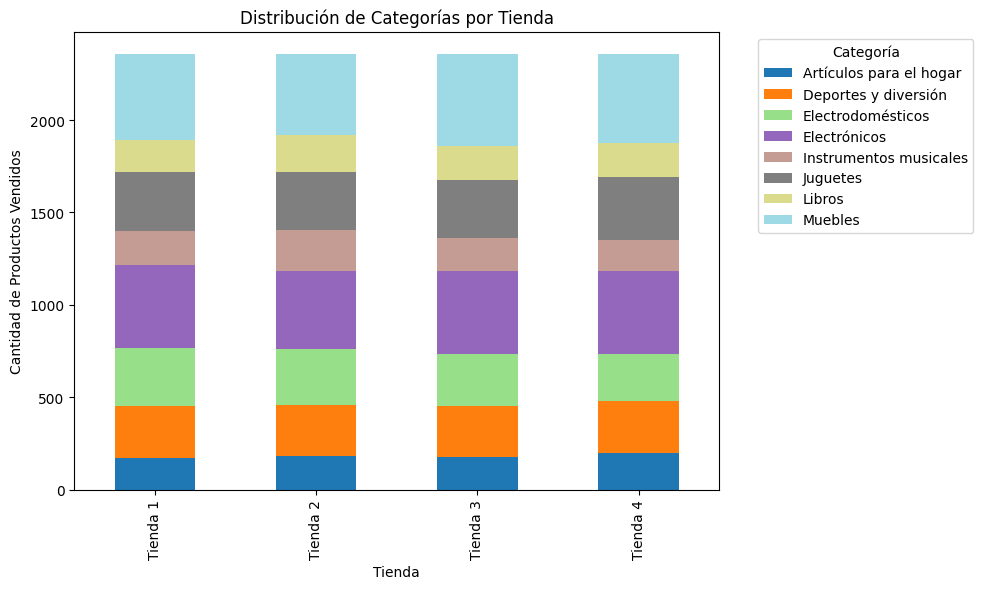

In [41]:
#Pivot para tener categorías como columnas
ventas_categoria_df = ventas_categoria.reset_index()
ventas_categoria_pivot = ventas_categoria_df.pivot(index='Tienda', columns='Categoría del Producto', values='Cantidad')

#Gráfico de barras apiladas
ventas_categoria_pivot.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')
plt.title('Distribución de Categorías por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Cantidad de Productos Vendidos')
plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


##Calificación promedio por tienda

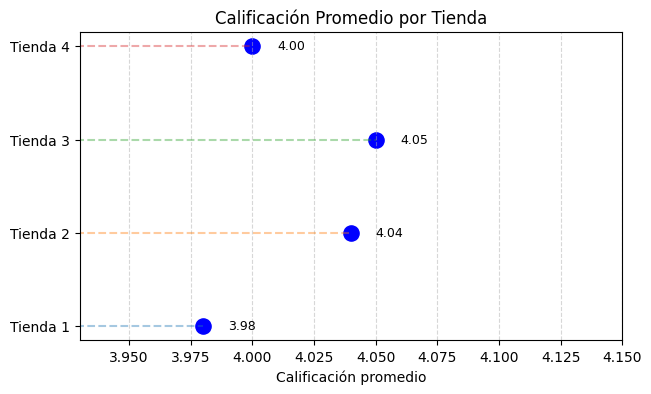

In [42]:
plt.figure(figsize=(7,4))

#Dibujar los puntos
plt.scatter(
    calificacion_promedio_df['Calificación'],
    calificacion_promedio_df['Tienda'],
    s=120,
    color='blue'
)

#Líneas guía horizontales
for i, tienda in enumerate(calificacion_promedio_df['Tienda']):
    plt.plot(
        [0, calificacion_promedio_df['Calificación'].iloc[i]],
        [tienda, tienda],
        linestyle='--',
        alpha=0.4
    )

#Mostrar valores sobre cada punto
for i, row in calificacion_promedio_df.iterrows():
    plt.text(
        row['Calificación'] + 0.01,  # un poquito a la derecha del punto
        row['Tienda'],
        f"{row['Calificación']:.2f}",
        va='center',
        fontsize=9
           )

plt.title('Calificación Promedio por Tienda')
plt.xlabel('Calificación promedio')
plt.xlim(
    min(calificacion_promedio_df['Calificación']) - 0.05,
    max(calificacion_promedio_df['Calificación']) + 0.1  # dejar espacio para los textos
        )
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


#**Análisis de Alura Store LATAM**

##Introducción

El propósito de este análisis es ayudar al Sr. Juan a decidir qué tienda vender para invertir en un nuevo negocio. Para ello, evaluamos cuatro tiendas considerando cinco factores clave:

1. Facturación total de cada tienda.
2. Categorías de productos más y menos vendidas.
3. Calificación promedio de los clientes.
4. Productos más y menos vendidos.
5. Costo promedio del envío.

Los datos fueron analizados usando Python, Pandas y Matploplib para la generaron gráficos que complementan la interpretación de los resultados.

##Desarrollo del análisis

1. **Facturación Total**

| Tienda   | Facturación Total |
| -------- | ----------------- |
| Tienda 1 | 1.150.880.000     |
| Tienda 2 | 1.116.344.000     |
| Tienda 3 | 1.098.020.000     |
| Tienda 4 | 1.038.376.000     |

![Gráfico de Facturación](https://i.imgur.com/shmclQj.png)

**Interpretación:**

Las tiendas tienen pequeñas diferencias en ventas totales.

La Tienda 1 es la con mayores ventas.

La Tienda 4 es la con menores ventas.


2. **Calificación promedio de clientes**

| Tienda   | Calificación Promedio |
| -------- | --------------------- |
| Tienda 1 | 3.98                  |
| Tienda 2 | 4.04                  |
| Tienda 3 | 4.05                  |
| Tienda 4 | 4.00                  |

![Calificacion Promedio](https://i.imgur.com/X1mvELW.png)

**Interpretación:**

La Tienda 3 es la mejor evaluda
La Tienda 1 es la peor evaluda

El motivo de la mala evaluación puede ser el alto flujo de clientes y la falta de personal para esta demanda, fallas en la logística o calidad. Se debería evualar para encontrar la o las areas con errores.


3. **Costo de envío promedio**

| Tienda   | Costo de Envío Promedio |
| -------- | ----------------------- |
| Tienda 1 | 26.018,61               |
| Tienda 2 | 25.216,24               |
| Tienda 3 | 24.805,68               |
| Tienda 4 | 23.459,46               |


**Interpretación:**

La tienda 1 es la que tiene el costo mas alto de envío, lo que puede ser uno de los factores de la baja satisfacción de los clientes y ver disminuido los margenes si es que la empresa absorve los costos de envío.

Por su parte la Tienda 2 tiene uno de los costos de envío mas bajos, lo que se puede traducir en mejores margenes si es que la empresa absorve el costo de envío.


4. **Productos más y menos vendidos**

**Tienda 1:** Las ventas las lideran los electrodomesticos y muebles. Ticket alto, pero los menos vendidos son productos raros o poco alineados al mix principal. Lo que nos puede indicar una mala gestión de inventario o mala alineación al catálogo.

**Tienda 2:** Las ventas las lideran un mix de tecnología, instrumentos musicales y accesorios. Con un bottom de muebles y electrónica. Nuevamente vemos una inconsitencia en categorías.

**Tienda 3:** Las ventas las lideran muebles y cocina. Categorías clara.
El bottom lo incluyen electroníca e instrumentos. Portafolio bien definido acorde al core de la tienda.

**Tienda 4:** Las ventas estan lideradas por un mix muy variado.
Bottom con electrodomésticos grandes. Demanda débil si la comparamos con las otras tiendas donde lideran.


**Interpretación:**

La Tienda 3 muestra un catálogo mas coherente y estable.

La Tienda 4 tiene el mix mas desordenado y no alineado a las otras tiendas.


5. **Las Categorías más y menos vendidas**

![Categorias](https://i.imgur.com/zUpYfBC.png)

Top 5 es similar en todas las tiendas.
Muebles, electrónicos y juguetes.

Pero en bottom 5 es donde vemos las principales diferencias.

**Tienda 1:** Electrodomésticos tanto en el top como el bottom. Muestra dispersión y mal control de SKU.

**Tiendas 2 y 3:** Tendencia parecida, electrodomésticos en bottom. Muestra debilidad general.

**Tienda 4:** Electrodomésticos, deportes y artículos para el hogar en bottom. Indicando disperción en la demanda.

**Interpretación:**

Tiendas 2 y 3 son las mas estables y con mejor salud a largo plazo.

Tienda 4 es la menos especializada y consistente.


##**Conclusión**

Dependiendo del objetivo del negocio:


**Si quiere vender por rendimiento operativo y comercial.**

Vender - Tienda 4

Razones:

Facturación más baja.

Mix de productos más inconsistente.

Desempeño débil en categorías clave.

A pesar de su bajo costo de envío, no logra transformar ese beneficio en ventas.


**Si quiere vender por problemas internos (calidad, logística, percepción del cliente)**

Vender - Tienda 1

Razones:

Peor calificación promedio de clientes.

Costo de envío más alto (ineficiencia).

Aun con la mayor facturación, puede tener problemas de fondo.


**Si quiere vender la tienda más atractiva (para obtener el mayor precio de venta)**

Vender - Tienda 1

Razón:

Es la más valiosa para un comprador debido a su facturación.
